In [4]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

In [5]:
useDeng = False
cameraNumber = 4
useFisheye = True

patternSize = (12, 8)
squareSize = 30
imgSize = (1280, 800)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [7]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "calib_mono_cz_30mm_diwakar"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'160_fov', _calib_folder_name
)
_webcam_calib_video = os.path.join(_webcam_calib_folder, "webcam_color.msgpack")
_webcam_calib_folder = os.path.join(_webcam_calib_folder)
_webcam_calib_pth = os.path.join(_webcam_calib_folder, "webcam_calibration.msgpack")

In [8]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
_video_length = 0

for _frame in _video_data:
    _video_length += 1

_video_file.close()

print('video length, ', _video_length)

video length,  2089


In [9]:
_frame.shape

(800, 1280)

In [10]:
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)

chessb_corners = []
counter = 0

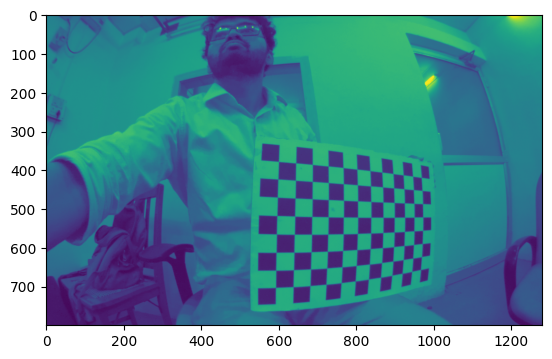

In [11]:
plt.imshow(_frame)

In [12]:
# for idx, frame in enumerate(tqdm(_video_data)):
def detectCorners(_frame):
    # _frame = cv2.rotate(_frame.copy(), cv2.ROTATE_180)

    ret, corners = cv2.findChessboardCorners(_frame, patternSize)
    if ret:
        corners = cv2.cornerSubPix(
            _frame,
            corners,
            (5, 5),
            (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
        )
    return corners
# Parallel execution with joblib
chessb_corners = []
results = Parallel(n_jobs=20, verbose=0)(
    delayed(detectCorners)(frame) for frame in tqdm(_video_data)
)


0it [00:00, ?it/s]

# Clean up the inhomogeneous  part

In [17]:
# Collect results
chessb_corners = []
for result in results:
    if result is not None and len(result) == 96:
        chessb_corners.append(result)

In [19]:
# Get the directory of the video file
video_dir = os.path.dirname(_video_pth)
corners_file = os.path.join(video_dir, "chessb_corners.msgpack")

with open(corners_file, "wb") as f:
    _packed_file = mp.packb(chessb_corners, default=mpn.encode)
    f.write(_packed_file)

# del(chessb_corners)

In [43]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Creating combinations

In [1]:
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
np.random.seed(9)

In [2]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_calib_folder_name = "calib_mono_160_better_view_2026"
_calib_folder_name = "calib_mono_120fov_1280_800_2026"
_calib_folder_name = "calib_mono_cz_30mm_diwakar"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",'160_fov', _calib_folder_name
)

_webcam_calib_video = os.path.join(_webcam_calib_folder, "webcam_color.msgpack")
_webcam_calib_folder = os.path.join(_webcam_calib_folder)
_webcam_corners_pth = os.path.join(_webcam_calib_folder, "chessb_corners.msgpack")

In [3]:
# load data

_corners_file = open(_webcam_corners_pth, "rb")
chessb_corners = list(mp.Unpacker(_corners_file, object_hook=mpn.decode))
chessb_corners = chessb_corners[0]
chessb_corners = np.array(chessb_corners)

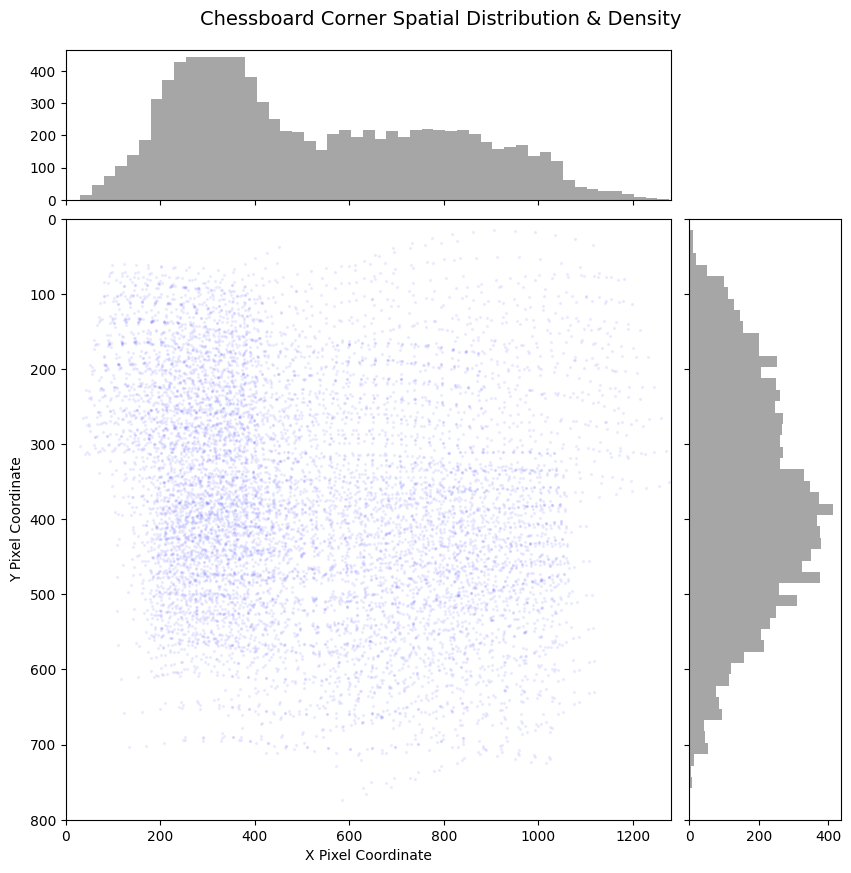

In [4]:
rnd = np.random.choice(len(chessb_corners), 100)
chessb_c = chessb_corners[rnd]

# 1. Reshape the data (same as before)
# Assuming 'corners' is your array of shape (6785, 24, 1, 2)
flat_corners = chessb_c.reshape(-1, 2)
x_coords = flat_corners[:, 0]
y_coords = flat_corners[:, 1]

# 2. Set up the Figure and Grid Layout
fig = plt.figure(figsize=(10, 10))

# Create a 2x2 grid. 
# The scatter plot takes up a 4x4 ratio, while the histograms take up a 1x4 and 4x1 ratio.
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      wspace=0.05, hspace=0.05)

# 3. Create the Axes
ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 4. Plot the Main Scatter Plot
ax_main.scatter(x_coords, y_coords, alpha=0.05, s=2, color='blue')
ax_main.set_xlabel('X Pixel Coordinate')
ax_main.set_ylabel('Y Pixel Coordinate')

# Invert the Y-axis so it matches image coordinates (origin top-left)
ax_main.invert_yaxis()

# 5. Plot the X-Axis Histogram (Top)
# We use 50 bins, but you can adjust this depending on your image resolution
ax_histx.hist(x_coords, bins=50, color='gray', alpha=0.7)
ax_histx.tick_params(axis="x", labelbottom=False) # Hide X labels to prevent overlap

# 6. Plot the Y-Axis Histogram (Right)
# Crucial: set orientation='horizontal' so the bars align with the scatter plot's Y-axis
ax_histy.hist(y_coords, bins=50, orientation='horizontal', color='gray', alpha=0.7)
ax_histy.tick_params(axis="y", labelleft=False) # Hide Y labels to prevent overlap

# Optional: Set limits if you know your camera resolution (e.g., 1920x1080)
ax_main.set_xlim(0, 1280)
ax_main.set_ylim(800, 0) # Remember this is flipped!

plt.suptitle('Chessboard Corner Spatial Distribution & Density', fontsize=14, y=0.92)
plt.show()

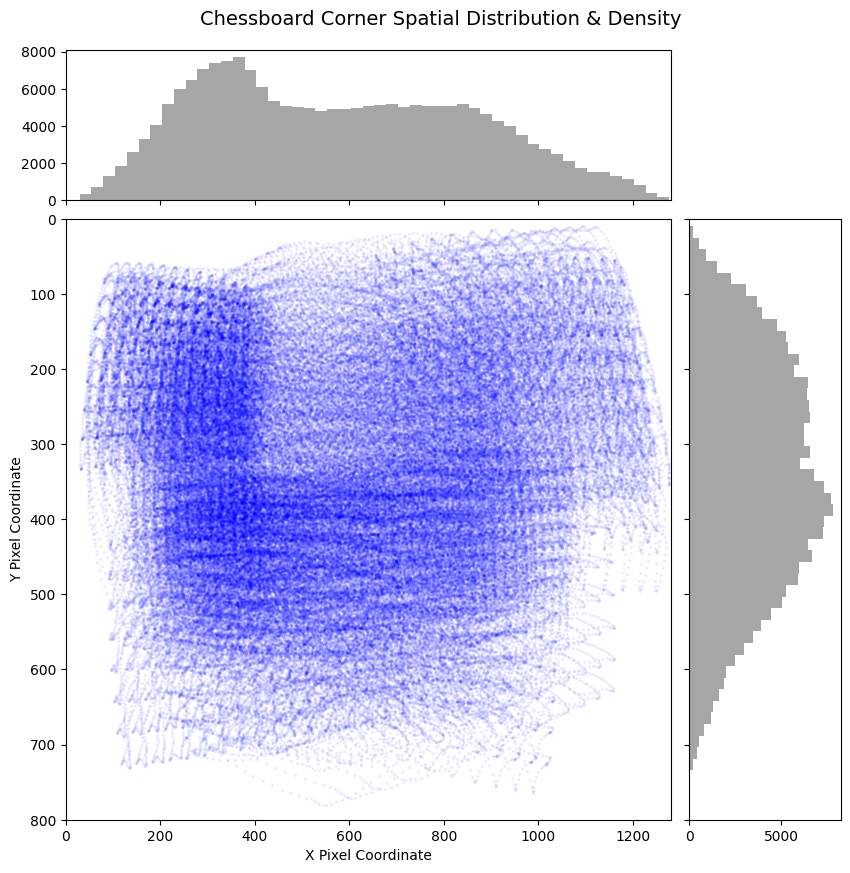

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Reshape the data (same as before)
# Assuming 'corners' is your array of shape (6785, 24, 1, 2)
flat_corners = chessb_corners.reshape(-1, 2)
x_coords = flat_corners[:, 0]
y_coords = flat_corners[:, 1]

# 2. Set up the Figure and Grid Layout
fig = plt.figure(figsize=(10, 10))

# Create a 2x2 grid. 
# The scatter plot takes up a 4x4 ratio, while the histograms take up a 1x4 and 4x1 ratio.
gs = fig.add_gridspec(2, 2, width_ratios=(4, 1), height_ratios=(1, 4),
                      wspace=0.05, hspace=0.05)


# 3. Create the Axes
ax_main = fig.add_subplot(gs[1, 0])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_histy = fig.add_subplot(gs[1, 1], sharey=ax_main)

# 4. Plot the Main Scatter Plot
ax_main.scatter(x_coords, y_coords, alpha=0.05, s=2, color='blue')
ax_main.set_xlabel('X Pixel Coordinate')
ax_main.set_ylabel('Y Pixel Coordinate')

# Invert the Y-axis so it matches image coordinates (origin top-left)
ax_main.invert_yaxis()

# 5. Plot the X-Axis Histogram (Top)
# We use 50 bins, but you can adjust this depending on your image resolution
ax_histx.hist(x_coords, bins=50, color='gray', alpha=0.7)
ax_histx.tick_params(axis="x", labelbottom=False) # Hide X labels to prevent overlap

# 6. Plot the Y-Axis Histogram (Right)
# Crucial: set orientation='horizontal' so the bars align with the scatter plot's Y-axis
ax_histy.hist(y_coords, bins=50, orientation='horizontal', color='gray', alpha=0.7)
ax_histy.tick_params(axis="y", labelleft=False) # Hide Y labels to prevent overlap

# Optional: Set limits if you know your camera resolution (e.g., 1920x1080)
ax_main.set_xlim(0, 1280)
ax_main.set_ylim(800, 0) # Remember this is flipped!

plt.suptitle('Chessboard Corner Spatial Distribution & Density', fontsize=14, y=0.92)
plt.show()

In [6]:
useDeng = False
cameraNumber = 4
useFisheye = True

patternSize = (12, 8)
squareSize = 30
imgSize = (1280, 800)

# criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)


def construct3DPoints(patternSize, squareSize):
    X = np.zeros((patternSize[0] * patternSize[1], 3), np.float32)
    X[:, :2] = np.mgrid[0 : patternSize[0], 0 : patternSize[1]].T.reshape(-1, 2)
    X = X * squareSize
    return X


boardPoints = construct3DPoints(patternSize, squareSize)

In [7]:
permute_value = 200

In [8]:


def calibrate_single_iteration(_):
    rnd = np.random.choice(len(chessb_corners), 90)
    chessb_c = chessb_corners[rnd]
    worldPoints = []
    imagePoints = []
    useFisheye = True

    for _f in chessb_c:
        imagePoints.append(_f)
        worldPoints.append(boardPoints)

    if useFisheye:
        flagsCalib = (
            cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC  # Vital for convergence
            + cv2.fisheye.CALIB_FIX_SKEW           # Sensors don't have skew
            + cv2.fisheye.CALIB_CHECK_COND         # Safety check
            # + cv2.fisheye.CALIB_FIX_K3             # See note below
            # + cv2.fisheye.CALIB_FIX_K4             # See note below
        )
        # 2. Set Flags for 160 deg / 15% distortion
        # flagsCalib = (
        #     cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
        #     # | cv2.fisheye.CALIB_FIX_SKEW 
        #     # | cv2.fisheye.CALIB_CHECK_COND
        #     # | cv2.fisheye.CALIB_FIX_PRINCIPAL_POINT 
        #     # Start by fixing higher order coeffs for low-distortion fisheyes
        #     # to prevent "wavy" edges. If RMS is bad, comment these out.
        #     # | cv2.fisheye.CALIB_FIX_K3 
        #     # | cv2.fisheye.CALIB_FIX_K4
        #     # | cv2.fisheye.CALIB_ZERO_DISPARITY
        # )

        # flagsCalib = (cv2.fisheye.CALIB_USE_INTRINSIC_GUESS
        # # | cv2.fisheye.CALIB_FIX_SKEW 
        # | cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC
        # | cv2.fisheye.CALIB_CHECK_COND
        # # | cv2.fisheye.CALIB_FIX_K4
        # )

        # f ~ 540 based on r/theta calculation for 1/4" sensor
        K_init = np.array([[540.0, 0.0, 640.0],
                        [0.0, 540.0, 400.0],
                        [0.0, 0.0, 1.0]])
        D_init = np.zeros((4, 1))



        calibrateCriteria = (
            cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
            500,
            # 1e-12,
            1e-9,
        )
        ret, cameraMatrix, k, R, t = cv2.fisheye.calibrate(
            np.expand_dims(np.asarray(worldPoints), -2),
            imagePoints,
            imgSize,
            None, # if we are not using the internsic guess
            None,
            # K_init,
            # D_init,
            flags=flagsCalib,
            criteria=calibrateCriteria,
        )
    else:
        flagsCalib = cv2.CALIB_RATIONAL_MODEL
        ret, cameraMatrix, k, R, t = cv2.calibrateCamera(
            worldPoints, imagePoints, imgSize, None, None, flags=flagsCalib
        )

    # print(worldPoints)
    return {"ReError": ret, "mat": cameraMatrix, "dist": k, "rvec": R, "tvec": t, 'rnd':rnd}


# Parallel execution with joblib
my_dict = {"ReError": [], "mat": [], "dist": [], "rvec": [], "tvec": [], 'rnd_value':[]}


results = Parallel(n_jobs=20, verbose=0)(
    delayed(calibrate_single_iteration)(_) for _ in tqdm(range(permute_value))
)
# Collect results
for result in results:
    my_dict["ReError"].append(result["ReError"])
    my_dict["mat"].append(result["mat"])
    my_dict["dist"].append(result["dist"])
    my_dict["rvec"].append(result["rvec"])
    my_dict["tvec"].append(result["tvec"])
    my_dict['rnd_value'].append(result['rnd'])


# calibrate_single_iteration(10)

  0%|          | 0/200 [00:00<?, ?it/s]

In [9]:
# video_dir = os.path.dirname(_video_pth)
if useFisheye:
    calibration_file = os.path.join(_webcam_calib_folder, f"calibration_data_{permute_value}.msgpack")
else:
    calibration_file = os.path.join(_webcam_calib_folder, f"standard_calibration_data_{permute_value}.msgpack")

with open(calibration_file, "wb") as f:
    _packed_file = mp.packb(my_dict, default=mpn.encode)
    f.write(_packed_file)

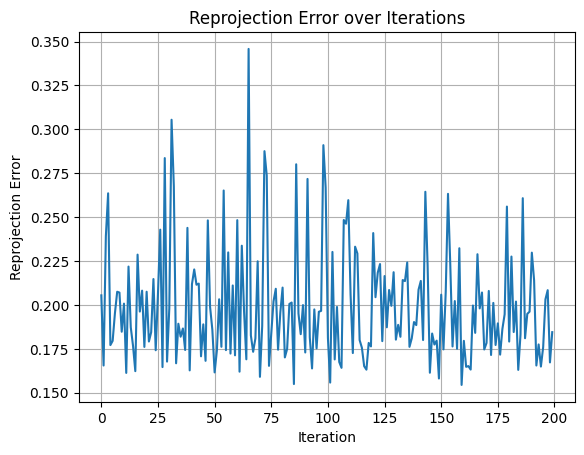

In [10]:
plt.plot(my_dict['ReError'])
plt.xlabel('Iteration')
plt.ylabel('Reprojection Error')
plt.title('Reprojection Error over Iterations')
plt.grid()

In [11]:
min_rerr_idx = np.argmin(my_dict['ReError'])
print('Minimum Reprojection Error:', my_dict['ReError'][min_rerr_idx], ' at index ', min_rerr_idx)

Minimum Reprojection Error: 0.15445371378354228  at index  159


In [12]:
rerr = my_dict['ReError'][min_rerr_idx]
camera_mat = my_dict['mat'][min_rerr_idx]
camera_dist = my_dict['dist'][min_rerr_idx]

In [13]:
print(rerr, camera_mat, camera_dist)

0.15445371378354228 [[595.13126432   0.         626.24113686]
 [  0.         596.61948898 464.18535783]
 [  0.           0.           1.        ]] [[-0.03995317]
 [ 0.00334538]
 [-0.00445543]
 [ 0.0004455 ]]


Translation Vector Standard Deviation: [230.69446628 115.05452764 121.59388824]


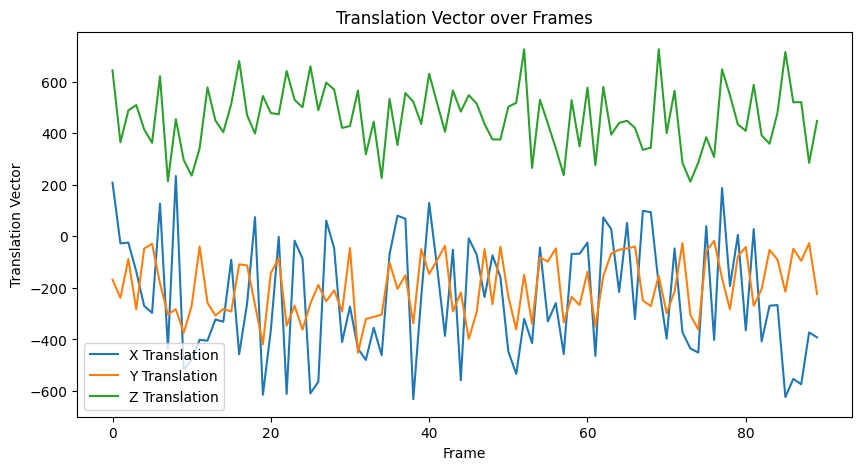

In [14]:
# plot the translation vector
tvec = my_dict['tvec'][0]
tvec = np.array(tvec).T[0]
plt.figure(figsize=(10, 5))
plt.plot(tvec[0], label='X Translation')
plt.plot(tvec[1], label='Y Translation')
plt.plot(tvec[2], label='Z Translation')
plt.xlabel('Frame')
plt.ylabel('Translation Vector')
plt.title('Translation Vector over Frames')
plt.legend()

# standard deviation of the translation vector
tvec_std = np.std(tvec, axis=1)
print('Translation Vector Standard Deviation:', tvec_std)

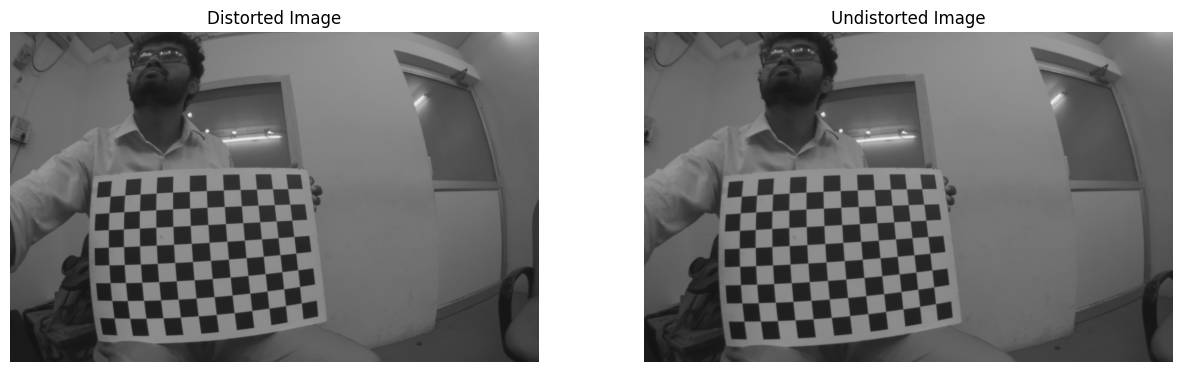

In [15]:
# show distorted and undistorted images
_video_pth = _webcam_calib_video
_video_file = open(_video_pth, "rb")
_video_data = mp.Unpacker(_video_file, object_hook=mpn.decode)
for idx, frame in enumerate(_video_data):
    # frame = cv2.flip(frame, 0)
    # frame = cv2.rotate(frame, cv2.ROTATE_180)
    frame_undistorted = cv2.undistort(frame, camera_mat, camera_dist)
    # create a subplot with 2 images and break at first image and plot chessboard corners
    
    if idx == 0:
        plt.figure(figsize=(15, 8))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        plt.title('Distorted Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(frame_undistorted, cv2.COLOR_BGR2RGB))
        plt.title('Undistorted Image')
        plt.axis('off')
        plt.show()
        break

In [ ]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

# Analysis by using a second video

In [1]:
import sys
import cv2
from cv2 import aruco
import numpy as np
import msgpack as mp
import msgpack_numpy as mpn
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import polars as pl
from datetime import datetime
    
sys.path.insert(1, os.path.dirname(os.getcwd()))
from pd_support import *
from scipy.spatial.transform import Rotation as R
import polars as pl
import os
from scipy.interpolate import interp1d
from joblib import Parallel, delayed

In [2]:
_pth = os.path.dirname(os.getcwd())
_parent_folder = "data"
_fov = "160_fov"
permute_value = 200

useFisheye = True

_calib_folder_name = "calib_mono_cz_30mm_diwakar"
# _recording_folder_name = "3marker_linear_2d_160fov_t1"
_recording_folder_name = "3marker_120fov_linear_ext_t0"
_recording_folder_name = "ref_recording_single_april_diwakar"

_level_folder_name = "ref_for_cameras"

_webcam_calib_folder = os.path.join(
    _pth,'..', _parent_folder, "calibration",_fov, _calib_folder_name
)

_reference_recording_folder = os.path.join(
    _pth, '..', _parent_folder, "recordings",_fov,_level_folder_name, _recording_folder_name
)
_reference_file = os.path.join(_reference_recording_folder, "webcam_color.msgpack")

_timestamp_file = os.path.join(_reference_recording_folder, "webcam_timestamp.msgpack")
with open(_timestamp_file, "rb") as f:
    _metadata = list(mp.Unpacker(f, object_hook=mpn.decode))
    _timestamp = np.array(_metadata)[:,1]
    _sync_pulse = np.array(_metadata)[:,0]

### load calibration combinations

In [3]:
if useFisheye:
    _calibration_data = os.path.join(_webcam_calib_folder, f'calibration_data_{permute_value}.msgpack')
else:
    _calibration_data = os.path.join(_webcam_calib_folder, f'standard_calibration_data_{permute_value}.msgpack')

with open(_calibration_data, 'rb') as f:
    my_dict = list(msgpack.Unpacker(f, object_hook=mpn.decode))
my_dict = my_dict[0]

In [4]:
_ref_video_length = 0

for _ in mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode):
    _ref_video_length += 1

print('video length, ', _ref_video_length)

video length,  6078


In [5]:
ARUCO_PARAMETERS = aruco.DetectorParameters()
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_APRILTAG_36h11)
detector = aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMETERS)
markerLength = 0.05
markerSeperation = 0.01

board = aruco.GridBoard(
    size=[1, 1],
    markerLength=markerLength,
    markerSeparation=markerSeperation,
    dictionary=ARUCO_DICT,
)

def estimate_pose_single_markers(
    corners, marker_size, camera_matrix, distortion_coefficients = np.zeros((5, 1))
):
    marker_points = np.array(
        [
            [-marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, marker_size / 2, 0],
            [marker_size / 2, -marker_size / 2, 0],
            [-marker_size / 2, -marker_size / 2, 0],
        ],
        dtype=np.float32,
    )
    rvecs, tvecs = [], []
    for corner in corners:
        _, r, t = cv2.solvePnP(
            marker_points,
            corner,
            camera_matrix,
            distortion_coefficients,
            flags=cv2.SOLVEPNP_ITERATIVE,
        )
        if r is not None and t is not None:
            rvecs.append(r.reshape(1, 3).tolist())
            tvecs.append(t.reshape(1, 3).tolist())
        else:
            rvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
            tvecs.append(np.array([[np.nan, np.nan, np.nan]]).tolist())
    return np.array(rvecs, dtype=np.float32), np.array(tvecs, dtype=np.float32)

## load clalibration data

In [6]:
_calib_data = list(mp.Unpacker(open(_calibration_data, "rb"), object_hook=mpn.decode))

In [7]:
len(_calib_data[0]['ReError'])

200

In [8]:
# selecting random 50 frames
np.random.seed(9)
_random_reference_frames_idx = np.random.choice(_ref_video_length, 300)

_ref_data = mp.Unpacker(open(_reference_file, "rb"), object_hook=mpn.decode)

# _ref_frames = []

ar_total_results = {'calib_idx':[], 'ar_data':[]}
ar_results = {'corners': [], 'ids': [], 'rejected': []}
vector_std = {'v1std':[], 'v2std':[], 'v3std':[], 'sum':[], 
              'r1std':[], 'r2std':[], 'r3std':[], 'r_sum':[]}

for idx, _frame in tqdm(enumerate(_ref_data)):
    # if idx in _random_reference_frames_idx:

        # _frame = cv2.rotate(_frame, cv2.ROTATE_180)
    # _frame = cv2.flip(_frame, 1)
    res = detector.detectMarkers(_frame,)
    
    res = detector.refineDetectedMarkers(_frame, board, res[0], res[1], res[2])
    ar_results['corners'].append(res[0])
    ar_results['ids'].append(res[1])
    ar_results['rejected'].append(res[2])

0it [00:00, ?it/s]

In [9]:
# ar_results['ids']

## path definition

In [9]:
_timestamp

array(['2026-06-18 14:47:08.705715', '2026-06-18 14:47:08.716092',
       '2026-06-18 14:47:08.728451', ..., '2026-06-18 14:48:09.525208',
       '2026-06-18 14:48:09.536408', '2026-06-18 14:48:09.545066'],
      shape=(6078,), dtype='<U26')

In [10]:
ar_df = {"time": _timestamp, "sync": _sync_pulse}
ar_df = pl.from_dict(ar_df)
if type(ar_df["time"][0]) is not datetime:
    ar_df = ar_df.with_columns(pl.col("time").str.to_datetime())

In [11]:
mocap_df, st_time = read_rigid_body_csv(
    os.path.join(_reference_recording_folder, f"{_recording_folder_name}.csv")
)
mocap_df = add_datetime_col(mocap_df, st_time, "seconds")
mocap_df = pl.from_pandas(mocap_df)

In [12]:
tr = get_rb_marker_name(5)
tl = get_rb_marker_name(6)
br = get_rb_marker_name(4)
bl = get_rb_marker_name(1)

# tr = get_rb_marker_name(8)
# tl = get_rb_marker_name(6)
# br = get_rb_marker_name(2)
# bl = get_rb_marker_name(5)


# tr = get_rb_marker_name(4)
# tl = get_rb_marker_name(2)
# br = get_rb_marker_name(3)
# bl = get_rb_marker_name(1)

In [13]:
ar_df['sync'][0]

'0'

In [14]:
ar_df = ar_df.with_columns(
    pl.col("sync").cast(pl.Int8).cast(pl.Boolean)
)

In [15]:
start_pulse = ar_df["sync"].arg_true().head(1).item()
offset = (~ar_df["sync"].slice(start_pulse)).arg_true().head(1).item()

end_pulse = start_pulse + offset

print(f"Start pulse: {start_pulse}, End pulse: {end_pulse}")
ar_df = ar_df[start_pulse:end_pulse]
ar_corners = ar_results['corners'][start_pulse:end_pulse]
ids = ar_results['ids'][start_pulse:end_pulse]

_time_diff = mocap_df["time"][0] - ar_df["time"][0]

ar_df = ar_df.with_columns([(pl.col("time") + _time_diff).alias("time")])

Start pulse: 343, End pulse: 5895


In [16]:
# ar_df

In [17]:
mocap_df["time"][0]

datetime.datetime(2026, 6, 18, 14, 47, 11, 941000)

In [18]:
ar_df["time"][0]

datetime.datetime(2026, 6, 18, 14, 47, 11, 941000)

In [19]:
_time_diff

datetime.timedelta(days=-1, seconds=86399, microseconds=805565)

In [20]:
mocap_mean = {"x": [], "y": [], "z": []}
mocap_mean["x"] = mocap_df[[tr["x"], tl["x"], br["x"], bl["x"]]].to_numpy().mean(axis=1)
mocap_mean["y"] = mocap_df[[tr["y"], tl["y"], br["y"], bl["y"]]].to_numpy().mean(axis=1)
mocap_mean["z"] = mocap_df[[tr["z"], tl["z"], br["z"], bl["z"]]].to_numpy().mean(axis=1)

mocap_qt_0 = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]][0].to_numpy()

mocap_rotation = R.from_quat(mocap_qt_0).as_matrix()

mocap_mean = pl.from_dict(mocap_mean)

mt_dict = {"x": [], "y": [], "z": []}
rmat_m = mocap_rotation[0]

for i in range(len(mocap_df["time"])):
    tvec_ar = rmat_m.T @ (
        mocap_mean[["x", "y", "z"]][i].to_numpy().reshape(3, 1)
        - mocap_mean[["x", "y", "z"]][0].to_numpy().reshape(3, 1)
    )
    tvec_ar = tvec_ar.T[0]
    mt_dict["x"].append(tvec_ar[0])
    mt_dict["y"].append(tvec_ar[1])
    mt_dict["z"].append(tvec_ar[2])

mt_dict["time"] = mocap_df["time"]

In [21]:
mc_angle_arr = mocap_df[["rb_ang_x", "rb_ang_y", "rb_ang_z", "rb_ang_w"]].to_numpy()
mocap_angle = []
mc_ang_x = []
mc_ang_y = []
mc_ang_z = []
for _a in mc_angle_arr:
    try:
        _ax, _ay, _az = R.from_matrix(
            mocap_rotation[0].T @ R.from_quat(_a).as_matrix()
        ).as_euler("xyz", degrees=True)
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)
    except:
        _ax, _ay, _az = R.from_matrix(mocap_rotation[0].T @ np.eye(3)).as_euler(
            "xyz", degrees=True
        )
        mc_ang_x.append(_ax)
        mc_ang_y.append(_ay)
        mc_ang_z.append(_az)

## Interoplating

In [22]:
mocap = pl.from_dict(mt_dict)

x1 = interp1d(mocap["time"].dt.epoch(), mocap["x"], fill_value="extrapolate")
y1 = interp1d(mocap["time"].dt.epoch(), mocap["y"], fill_value="extrapolate")
z1 = interp1d(mocap["time"].dt.epoch(), mocap["z"], fill_value="extrapolate")

ax = interp1d(mocap["time"].dt.epoch(), mc_ang_x, fill_value="extrapolate")
ay = interp1d(mocap["time"].dt.epoch(), mc_ang_y, fill_value="extrapolate")
az = interp1d(mocap["time"].dt.epoch(), mc_ang_z, fill_value="extrapolate")

mocap_ip = {"time": ar_df["time"]}
mocap_ip["x"] = x1(ar_df["time"].dt.epoch())
mocap_ip["y"] = y1(ar_df["time"].dt.epoch())
mocap_ip["z"] = z1(ar_df["time"].dt.epoch())
mocap_ip["rx"] = ax(ar_df["time"].dt.epoch())
mocap_ip["ry"] = ay(ar_df["time"].dt.epoch())
mocap_ip["rz"] = az(ar_df["time"].dt.epoch())

R_opt = np.array([
    [ 0.98458659, -0.03644425,  0.17105865],
    [ 0.07710029,  0.96832946, -0.23747339],
    [-0.15698659,  0.24700179,  0.95621406],
])
t_opt = np.array([-0.00798871, -0.01317108, 0.00632256])

# stack x,y,z -> (N,3), align, write back
mocap_array = np.column_stack([mocap_ip["x"], mocap_ip["y"], mocap_ip["z"]])
aligned_mocap = (R_opt @ mocap_array.T).T + t_opt
mocap_ip["x"], mocap_ip["y"], mocap_ip["z"] = (
    aligned_mocap[:, 0],
    aligned_mocap[:, 1],
    aligned_mocap[:, 2],
)

mocap_ip = pl.from_dict(mocap_ip)

In [23]:
default_ids = [12, 14, 20]

In [24]:
len(my_dict["mat"])

200

In [25]:
from joblib import Parallel, delayed
import numpy as np
import cv2
from scipy.spatial.transform import Rotation as R
from tqdm import tqdm

def projected_trajectory_smoothness(trajectory, axes):
    """RMS second difference in a 2D projection; lower is smoother."""
    projected = np.asarray(trajectory, dtype=float)[:, axes]
    valid = np.isfinite(projected).all(axis=1)
    second_differences = []

    # Process contiguous valid runs so missing frames are not bridged.
    valid_indices = np.flatnonzero(valid)
    if valid_indices.size == 0:
        return np.nan

    for run in np.split(valid_indices, np.where(np.diff(valid_indices) > 1)[0] + 1):
        if run.size >= 3:
            second_differences.append(np.diff(projected[run], n=2, axis=0))

    if not second_differences:
        return np.nan

    acceleration = np.vstack(second_differences)
    return np.sqrt(np.mean(np.sum(acceleration ** 2, axis=1)))

def process_single_iteration(i, fish_mat, fish_dist, all_corners_concat, corner_counts, mocap_x, mocap_y, mocap_z):
    """Process a single iteration of the calibration loop"""

    if useFisheye:
    
        _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
            fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
        )

        # Batch undistort
        undist_all = cv2.fisheye.undistortPoints(
            all_corners_concat, fish_mat, fish_dist, None, _new_cam
        )
    else:
        _new_cam, roi = cv2.getOptimalNewCameraMatrix(
            fish_mat, 
            fish_dist, 
            (1280, 800), 
            1.0,  # alpha
            (1280, 800)
        )
        fish_dist = fish_dist
        undist_all = all_corners_concat
    
    # Split back into individual corner sets
    undist_corners = []
    idx = 0
    for count in corner_counts:
        if count > 0:
            undist_corners.append(undist_all[idx:idx+count])
            idx += count
        else:
            undist_corners.append(None)
    
    # Pre-allocate arrays
    num_markers = len(undist_corners)
    rvecs = np.full((num_markers, 3), np.nan)
    tvecs = np.full((num_markers, 3), np.nan)
    
    for idx, _c in enumerate(undist_corners):
        if _c is not None:  # Already filtered for ID 12
            num_detected_markers = _c.shape[0] // 4
            reshaped_corners = [
                _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
                for j in range(num_detected_markers)
            ]
            
            rotation_vectors, translation_vectors = estimate_pose_single_markers(
                corners=reshaped_corners,
                marker_size=0.048,
                camera_matrix=fish_mat,
                distortion_coefficients=fish_dist,
            )
            
            if rotation_vectors is not None and len(rotation_vectors) > 0:
                rvecs[idx] = rotation_vectors[0][0]
                tvecs[idx] = translation_vectors[0][0]
    
    # Find first valid (non-NaN) marker to use as reference
    valid_idx = None
    for idx in range(len(rvecs)):
        if not np.isnan(rvecs[idx]).any():
            valid_idx = idx
            break
    
    # If no valid markers found, return NaN
    if valid_idx is None:
        return {
            'err_x': np.nan,
            'err_y': np.nan,
            'err_z': np.nan,
            'mean_err': np.nan,
            'smoothness_xy': np.nan,
            'smoothness_xz': np.nan,
            'idx': i,
            'tvecs': np.full((num_markers, 3), np.nan)
        }
    
    # Vectorize transformation calculations using first valid marker as reference
    rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
    rmat_T = rmat.T
    
    # Vectorized translation transformation
    tvec_diff = tvecs - tvecs[valid_idx]
    tvec_transformed = (rmat_T @ tvec_diff.T).T

    # axis flipped
    transformed_tvecs = tvec_transformed.copy()
    # transformed_tvecs[:, 0] = tvec_transformed[:, 1]
    # transformed_tvecs[:, 1] = tvec_transformed[:, 2]
    # transformed_tvecs[:, 2] = tvec_transformed[:, 0]

    # Vectorize error calculations
    _ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - mocap_x))
    _ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - mocap_y))
    _ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - mocap_z))
    _mean_err = np.nanmean([_ex, _ey, _ez])
    
    _max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - mocap_x))
    _max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - mocap_y))
    _max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - mocap_z))

    # Projected trajectory smoothness (distance per frame squared).
    _smoothness_xy = projected_trajectory_smoothness(transformed_tvecs, axes=(0, 1))
    _smoothness_xz = projected_trajectory_smoothness(transformed_tvecs, axes=(0, 2))
    
    return {
        'err_x': _max_x,
        'err_y': _max_y,
        'err_z': _max_z,
        'mean_err': _mean_err,
        'smoothness_xy': _smoothness_xy,
        'smoothness_xz': _smoothness_xz,
        'idx': i,
        'tvecs': transformed_tvecs
    }


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Batch undistort - collect all valid corners first, ONLY for ID 12
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

print(f"Found {sum(1 for c in corner_counts if c > 0)} valid corners with ID 12 out of {len(corner_counts)} total")

# Check if we have any valid corners
if not all_corners_list:
    raise ValueError("No valid corners found for ID 12! Check your filtering logic.")

# Concatenate all corners for batch processing
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)
print(f"Concatenated corners shape: {all_corners_concat.shape}")

# Pre-compute mocap arrays once
mocap_x = mocap_ip["x"].to_numpy()
mocap_y = mocap_ip["y"].to_numpy()
mocap_z = mocap_ip["z"].to_numpy()

# Parallel processing
n_jobs = 12  # Adjust based on your CPU cores (-1 for all cores)
print(f"Processing {len(my_dict['mat'])} iterations with {n_jobs} parallel jobs...")

results = Parallel(n_jobs=n_jobs, verbose=10)(
    delayed(process_single_iteration)(
        i, 
        my_dict["mat"][i], 
        my_dict["dist"][i],
        all_corners_concat,
        corner_counts,
        mocap_x,
        mocap_y,
        mocap_z
    )
    for i in range(len(my_dict["mat"]))
)

# Collect results into dictionary
error_dict = {
    "err_x": [r['err_x'] for r in results],
    "err_y": [r['err_y'] for r in results],
    "err_z": [r['err_z'] for r in results],
    "mean_err": [r['mean_err'] for r in results],
    "smoothness_xy": [r['smoothness_xy'] for r in results],
    "smoothness_xz": [r['smoothness_xz'] for r in results],
    "idx": [r['idx'] for r in results],
    "tvecs": [r['tvecs'] for r in results]
}

print("Processing complete!")
print(f"Valid results: {sum(1 for x in error_dict['mean_err'] if not np.isnan(x))}/{len(error_dict['mean_err'])}")
print(f"Mean error (excluding NaN): {np.nanmean(error_dict['mean_err']):.4f}")
print(f"Mean XY smoothness (lower is better): {np.nanmean(error_dict['smoothness_xy']):.6f}")
print(f"Mean XZ smoothness (lower is better): {np.nanmean(error_dict['smoothness_xz']):.6f}")

Filtering corners for ID 12...
Found 5532 valid corners with ID 12 out of 5552 total
Concatenated corners shape: (22128, 1, 2)
Processing 200 iterations with 12 parallel jobs...


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:    2.9s
[Parallel(n_jobs=12)]: Done   8 tasks      | elapsed:    3.0s
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    5.7s
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    8.4s
[Parallel(n_jobs=12)]: Done  37 tasks      | elapsed:   11.3s
[Parallel(n_jobs=12)]: Done  48 tasks      | elapsed:   11.6s
[Parallel(n_jobs=12)]: Done  61 tasks      | elapsed:   16.9s
[Parallel(n_jobs=12)]: Done  74 tasks      | elapsed:   19.8s
[Parallel(n_jobs=12)]: Done  89 tasks      | elapsed:   22.9s
[Parallel(n_jobs=12)]: Done 104 tasks      | elapsed:   25.8s
[Parallel(n_jobs=12)]: Done 121 tasks      | elapsed:   31.1s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:   34.4s
[Parallel(n_jobs=12)]: Done 157 tasks      | elapsed:   39.6s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   43.3s


Processing complete!
Valid results: 200/200
Mean error (excluding NaN): 0.0630
Mean XY smoothness (lower is better): 0.011008
Mean XZ smoothness (lower is better): 0.014731


[Parallel(n_jobs=12)]: Done 198 out of 200 | elapsed:   48.2s remaining:    0.4s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:   48.4s finished


In [26]:
error_field = 'smoothness_xz' 
min_index = np.argmin(error_dict[error_field])
# min_index = 8
print(error_dict[error_field][min_index], 'min index: ', min_index)

0.014051053751283373 min index:  46


# Evaluation section

### Align mocap

In [27]:
import numpy as np
from scipy.spatial.transform import Rotation as R_scipy

def align_trajectories(source, target):
    """
    Aligns source array to target array using the Kabsch algorithm.
    Both arrays should be of shape (N, 3).
    Returns the rotation matrix, translation vector, and Euler angles in degrees.
    """
    # 1. Calculate centroids and center the data
    centroid_source = np.mean(source, axis=0)
    centroid_target = np.mean(target, axis=0)
    source_centered = source - centroid_source
    target_centered = target - centroid_target

    # 2. Calculate covariance matrix H and perform SVD
    H = source_centered.T @ target_centered
    U, S, Vt = np.linalg.svd(H)

    # 3. Calculate the optimal rotation matrix R
    R = Vt.T @ U.T

    # 4. Handle reflection case
    if np.linalg.det(R) < 0:
        Vt[2, :] *= -1
        R = Vt.T @ U.T

    # 5. Calculate the translation vector t
    t = centroid_target - R @ centroid_source

    # ---------------------------------------------------------
    # NEW: Convert the 3x3 Rotation Matrix to Euler Angles
    # ---------------------------------------------------------
    # We use 'xyz' order (pitch, yaw, roll). 
    # The order matters in 3D space, but 'xyz' is the most intuitive 
    # for reading "rotation around X, then Y, then Z".
    rotation_obj = R_scipy.from_matrix(R)
    angles_degrees = rotation_obj.as_euler('xyz', degrees=True)

    return R, t, angles_degrees


In [28]:
all_corners_list = []
corner_counts = []
print("Filtering corners for ID 12...")
for _corner, _id in zip(ar_corners, ids):
    try:
        id_index = _id.reshape(-1).tolist().index(12)
        all_corners_list.append(np.array(_corner[id_index]).reshape(-1, 2))
        corner_counts.append(len(np.array(_corner[id_index]).reshape(-1, 2)))
    except:
        corner_counts.append(0)
all_corners_concat = np.vstack(all_corners_list).reshape(-1, 1, 2)

_i = min_index
fish_mat = my_dict["mat"][_i]
fish_dist = my_dict["dist"][_i]
if useFisheye:

    _new_cam = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        fish_mat, fish_dist, (1280, 800), np.eye(3), balance=1
    )
    
    # Batch undistort
    undist_all = cv2.fisheye.undistortPoints(
        all_corners_concat, fish_mat, fish_dist, None, _new_cam
    )
else:
    _new_cam = fish_mat
    fish_dist = fish_dist[:4]
    undist_all = all_corners_concat

# Split back into individual corner sets
undist_corners = []
idx = 0
for count in corner_counts:
    if count > 0:
        undist_corners.append(undist_all[idx:idx+count])
        idx += count
    else:
        undist_corners.append(None)

# Pre-allocate arrays
num_markers = len(undist_corners)
rvecs = np.full((num_markers, 3), np.nan)
tvecs = np.full((num_markers, 3), np.nan)

for idx, _c in enumerate(undist_corners):
    if _c is not None:  # Already filtered for ID 12
        num_detected_markers = _c.shape[0] // 4
        reshaped_corners = [
            _c[j * 4:(j + 1) * 4].reshape(4, 1, 2)
            for j in range(num_detected_markers)
        ]
        
        rotation_vectors, translation_vectors = estimate_pose_single_markers(
            corners=reshaped_corners,
            marker_size=0.047,
            camera_matrix=_new_cam,
            distortion_coefficients=fish_dist,
        )
        
        if rotation_vectors is not None and len(rotation_vectors) > 0:
            rvecs[idx] = rotation_vectors[0][0]
            tvecs[idx] = translation_vectors[0][0]

# Find first valid (non-NaN) marker to use as reference
valid_idx = None
for idx in range(len(rvecs)):
    if not np.isnan(rvecs[idx]).any():
        valid_idx = idx
        break

# Vectorize transformation calculations using first valid marker as reference
rmat = cv2.Rodrigues(rvecs[valid_idx])[0]
rmat_T = rmat.T

# Vectorized translation transformation
tvec_diff = tvecs - tvecs[valid_idx]
tvec_transformed = (rmat_T @ tvec_diff.T).T

# axis flipped
transformed_tvecs = tvec_transformed.copy()
# transformed_tvecs[:, 0] = tvec_transformed[:, 1]
# transformed_tvecs[:, 1] = tvec_transformed[:, 2]
# transformed_tvecs[:, 2] = tvec_transformed[:, 0]

# Vectorize error calculations
_ex = np.nanmean(np.abs(transformed_tvecs[:, 0] - mocap_x))
_ey = np.nanmean(np.abs(transformed_tvecs[:, 1] - mocap_y))
_ez = np.nanmean(np.abs(transformed_tvecs[:, 2] - mocap_z))

_mean_err = np.nanmean([_ex, _ey, _ez])

# filtering out 95th percentile

_ex_arr = np.abs(transformed_tvecs[:, 0] - mocap_x)
_px = np.nanpercentile(_ex_arr, 95)
_ex_p = np.nanmax(_ex_arr[_ex_arr <= _px])

_ey_arr = np.abs(transformed_tvecs[:, 1] - mocap_y)
_py = np.nanpercentile(_ey_arr, 95)
_ey_p = np.nanmax(_ey_arr[_ey_arr <= _py])
    
_ez_arr = np.abs(transformed_tvecs[:, 2] - mocap_z)
_pz = np.nanpercentile(_ez_arr, 95)
_ez_p = np.nanmax(_ez_arr[_ez_arr <= _pz])

_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - mocap_x))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - mocap_y))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - mocap_z))

print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")
print(f"Max error 95th percentile: X={_ex_p}, Y={_ey_p}, Z={_ez_p}")

Filtering corners for ID 12...
Max error: X=0.03043063442555366, Y=0.03414803660855212, Z=0.024670563845867348
Max error 95th percentile: X=0.018010377293219665, Y=0.013384703966132358, Z=0.011587658642253432


In [29]:
# # --- How to use it ---

# # Assuming 'clean_mocap' and 'clean_apriltag' from the previous step:
# R_opt, t_opt, euler_deg = align_trajectories(clean_mocap, clean_apriltag)

# print(f"Rotation around X-axis: {euler_deg[0]:.2f} degrees")
# print(f"Rotation around Y-axis: {euler_deg[1]:.2f} degrees")
# print(f"Rotation around Z-axis: {euler_deg[2]:.2f} degrees")

# # Apply the transformation to your original array as usual
# aligned_mocap = (R_opt @ mocap_array.T).T + t_opt

In [30]:
mocap_array = np.array([mocap_x, mocap_y, mocap_z]).T
apriltag_array = tvec_transformed



# 1. Create a boolean mask of rows where ALL values are finite (no NaNs or Infs)
# We check both arrays to ensure we only keep frames where BOTH systems had tracking
valid_mask = np.isfinite(mocap_array).all(axis=1) & np.isfinite(apriltag_array).all(axis=1)

# 2. Apply the mask to filter both arrays
clean_mocap = mocap_array[valid_mask]
clean_apriltag = apriltag_array[valid_mask]

# Optional: Print to see how many frames were dropped
print(f"Original frames: {len(mocap_array)}")
print(f"Cleaned frames: {len(clean_mocap)}")
print(f"Dropped frames: {len(mocap_array) - len(clean_mocap)}")

# # 3. Now run the alignment on the clean data!
R_opt, t_opt, euler_deg = align_trajectories(clean_mocap, clean_apriltag)

# # 4. Apply the transformation to the ORIGINAL mocap array 
# # (This ensures your final array still matches the original 6703 length, 
# # keeping the NaNs where tracking was lost)
aligned_mocap = (R_opt @ mocap_array.T).T + t_opt



Original frames: 5552
Cleaned frames: 5530
Dropped frames: 22


In [31]:
print(R_opt, t_opt)

[[ 0.99992555 -0.00460504 -0.01129963]
 [ 0.00441768  0.99985327 -0.01655044]
 [ 0.01137419  0.01649929  0.99979918]] [-0.00021068  0.00108442  0.00133843]


In [32]:
_max_x = np.nanmax(np.abs(transformed_tvecs[:, 0] - aligned_mocap[:, 0]))
_max_y = np.nanmax(np.abs(transformed_tvecs[:, 1] - aligned_mocap[:, 1]))
_max_z = np.nanmax(np.abs(transformed_tvecs[:, 2] - aligned_mocap[:, 2]))
print(f"Max error: X={_max_x}, Y={_max_y}, Z={_max_z}")

Max error: X=0.027184133443812486, Y=0.03321868363744593, Z=0.024801750344397865


### Evaluating a section to see everything is right

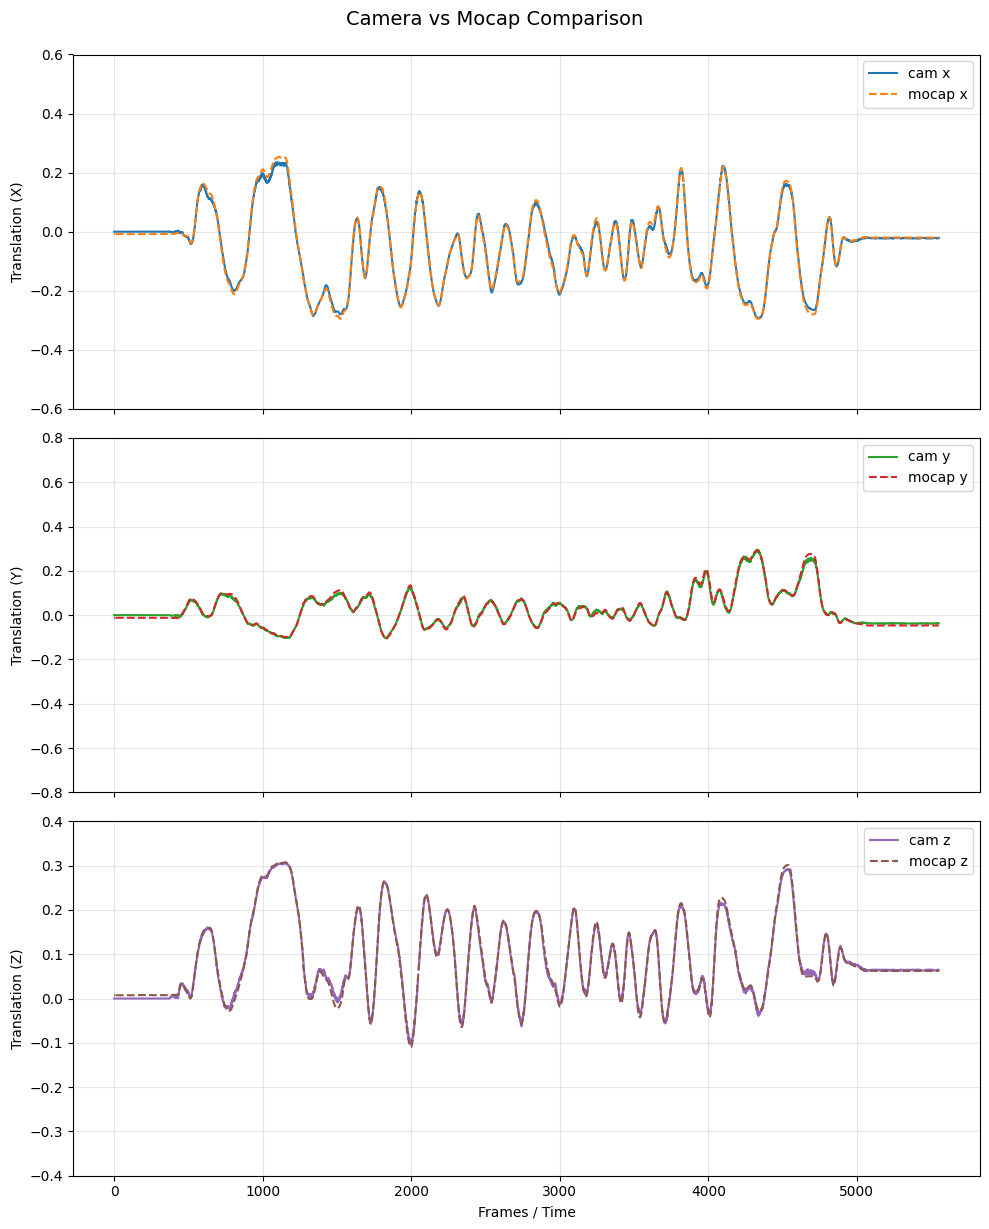

In [33]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots (rows), sharing the same x-axis
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Subplot for X
axes[0].plot(tvec_transformed[:, 0], label="cam x", color='tab:blue')
axes[0].plot(aligned_mocap[:, 0], label="mocap x", color='tab:orange', linestyle='--')
axes[0].set_ylabel("Translation (X)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.6, 0.6)


# Subplot for Y
axes[1].plot(tvec_transformed[:, 1], label="cam y", color='tab:green')
axes[1].plot(aligned_mocap[:, 1], label="mocap y", color='tab:red', linestyle='--')
axes[1].set_ylabel("Translation (Y)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.8, 0.8)

# Subplot for Z
axes[2].plot(tvec_transformed[:, 2], label="cam z", color='tab:purple')
axes[2].plot(aligned_mocap[:,2], label="mocap z", color='tab:brown', linestyle='--')
# axes[2].plot(mocap_z, label="mocap z", color='tab:brown', linestyle='--')
axes[2].set_ylabel("Translation (Z)")
axes[2].set_xlabel("Frames / Time")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.4, 0.4)

# Adjust layout to prevent label overlapping
plt.tight_layout()
plt.suptitle("Camera vs Mocap Comparison", y=1.02, fontsize=14)
plt.show()


C:\Users\Pintu\AppData\Local\Temp\ipykernel_18472\672892687.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


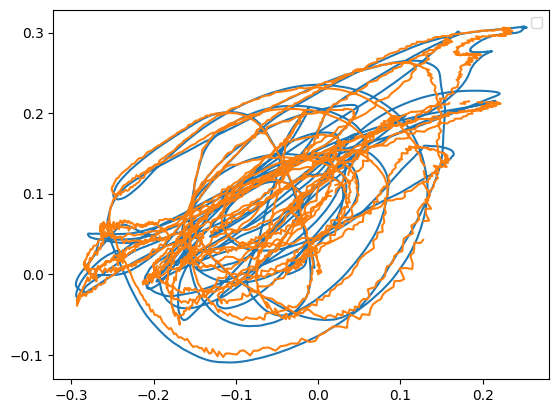

In [34]:
plt.plot(aligned_mocap[:,0], aligned_mocap[:,2])
# plt.plot(mocap_x, mocap_z)
plt.plot(tvec_transformed[:, 0], tvec_transformed[:, 2])
plt.legend()
plt.show()

In [35]:
STOP_HERE

NameError: name 'STOP_HERE' is not defined

In [36]:
import toml

data = toml.load(r"E:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\calibration\output\template.toml")
data["calibration"]["camera_matrix"] = my_dict["mat"][min_index].tolist()
data["calibration"]["dist_coeffs"] = my_dict["dist"][min_index].tolist()
data["calibration"]["pattern_size"] = (12, 8)
data['calibration']['notes'] = "Calibration performed using AprilTag 36h11 markers, with a 30mm lens. The calibration was validated against mocap data, and the optimal transformation was applied to align the camera's translation vectors with the mocap system."

data["camera"]["resolution"] = (1280, 800)


with open(
    r"E:\CMC\pyprojects\programs_rpi\NOARK_backbone\notebooks\calibration\output\diwakar_calibration_smoothness_xz.toml", "w"
) as f:
    toml.dump(data, f)